# TSV Frozen-Head Study (Standalone, Frozen-Only)
## Companion to the separate "TSV OpenCLIP LR grid" notebook (trainable head)

This notebook is **fully self-contained** and tests the **frozen,
text-encoder-derived classifier head only** -- it does not run a
trainable-head study, and it does not load or depend on any file from
another notebook. Everything it needs (imports, data loading, model
classes) is defined here.

Classification uses CLIP's own text encoder: for each class, embed
`"a photo of a {class_name}"` (frozen, never trained), then classify by
cosine similarity between that and the image embedding. Only the TSV
vector(s) are ever trained -- not the backbone, not the head.

**Cost**: 128 runs (5 phases), `EPOCHS=10` each, roughly ~2.5-3 hours.

**Note**: since this file has no access to trainable-head numbers, it
cannot run the trainable-vs-frozen comparison from before. If you want
that comparison, look at the separate "trainable + frozen" combined
notebook, or compare the saved JSON files from this notebook and the
trainable-head notebook manually afterward.

## 1. Setup and Installation

In [1]:
# Mount Google Drive (needed later for saving results, and if your
# professor's dataset folder is shared into your own Drive)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
try:
    import gdown
    print("Required packages already present, skipping install.")
except ImportError:
    import subprocess
    import sys

    packages = [
        'transformers',
        'torch',
        'torchvision',
        'accelerate',
        'datasets',
        'numpy',
        'matplotlib',
        'tqdm',
        'scikit-learn',
        'gdown',
    ]

    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
    print("Installation complete!")


Required packages already present, skipping install.


In [3]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 42.41 GB


## 2. Import Libraries and Setup

In [4]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import json
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## 3. Data Preparation

In [5]:
import os
import shutil

# Your own Drive -- this is where we cache a permanent copy of the dataset
# so we never have to re-download it after the first time.
DRIVE_CACHE_DIR = '/content/drive/MyDrive/cifar10_cache'
DRIVE_CACHE_PATH = os.path.join(DRIVE_CACHE_DIR, 'cifar-10-batches-py')

# Where torchvision.datasets.CIFAR10 expects to find the data locally
LOCAL_DATA_DIR = 'data'
LOCAL_CACHE_PATH = os.path.join(LOCAL_DATA_DIR, 'cifar-10-batches-py')

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_CACHE_PATH):
    # Already unpacked on THIS session's local disk (e.g. you re-ran this
    # cell without disconnecting) -- nothing to do.
    print(f"Already present locally at {LOCAL_CACHE_PATH}, skipping.")

elif os.path.exists(DRIVE_CACHE_PATH):
    # Fast path: we've cached this in your own Drive before. Copying
    # within Google's own storage is quick -- no external download.
    print("Found cached dataset in your Drive -- copying to local disk...")
    shutil.copytree(DRIVE_CACHE_PATH, LOCAL_CACHE_PATH)
    print(f"Copied to {LOCAL_CACHE_PATH}")

else:
    # Slow path, first time only: download from your professor's shared
    # Drive folder, then save a permanent copy into your own Drive for
    # every future session.
    print("Not cached yet -- downloading from professor's Drive folder...")
    folder_id = '1NZyI_UOHtSOlqpoivZqBiITy1hvM0Idc'
    !gdown --folder --id {folder_id}

    # See exactly what landed on disk before assuming a folder name --
    # if your professor's folder isn't literally named 'cifar-10-batches-py',
    # update `downloaded_name` below to match what gets printed here.
    print("Downloaded contents of current directory:", os.listdir('.'))
    downloaded_name = 'cifar-10-batches-py'

    if not os.path.exists(downloaded_name):
        raise FileNotFoundError(
            f"Couldn't find '{downloaded_name}' after download. Check the "
            f"directory listing printed above and update `downloaded_name` "
            f"to match what actually got downloaded."
        )

    # Move into place for torchvision
    shutil.move(downloaded_name, LOCAL_CACHE_PATH)
    print(f"Moved to {LOCAL_CACHE_PATH}")

    # Save a permanent copy to YOUR Drive so future sessions skip the
    # download entirely
    os.makedirs(DRIVE_CACHE_DIR, exist_ok=True)
    shutil.copytree(LOCAL_CACHE_PATH, DRIVE_CACHE_PATH)
    print(f"Cached a permanent copy to {DRIVE_CACHE_PATH} for next time.")

print("\nFinal local data contents:", os.listdir(LOCAL_DATA_DIR))


Found cached dataset in your Drive -- copying to local disk...
Copied to data/cifar-10-batches-py

Final local data contents: ['cifar-10-batches-py']


In [6]:
# Define data transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Load CIFAR-10 dataset
# FIX: download=False now -- the data is already sitting in ./data from the
# Google Drive download above, so we don't need (or want) torchvision to
# reach out to the official site at all.
print("Loading CIFAR-10 dataset from local ./data ...")
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

# Use subset for faster training
subset_size_train = 5000  # 10% of training data
subset_size_test = 1000   # 20% of test data

train_dataset, _ = random_split(
    train_dataset,
    [subset_size_train, len(train_dataset) - subset_size_train]
)

test_dataset, _ = random_split(
    test_dataset,
    [subset_size_test, len(test_dataset) - subset_size_test]
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of classes: 10")
print(f"Input shape: (3, 32, 32)")


Loading CIFAR-10 dataset from local ./data ...
Train dataset size: 5000
Test dataset size: 1000
Number of classes: 10
Input shape: (3, 32, 32)


In [7]:
# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 79
Test batches: 16


## 4. Training and Evaluation Functions

In [8]:
def resize_images(images, target_size=224):
    """Resize CIFAR-10 images (32x32) to target size for ViT"""
    from torchvision.transforms import Resize
    resizer = Resize((target_size, target_size))
    return resizer(images)

def train_epoch(model, train_loader, optimizer, criterion, device, epoch, total_epochs):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)

    for images, labels in pbar:
        # Resize images for ViT
        images = resize_images(images, target_size=224)
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        pbar.set_postfix({
            'loss': total_loss / (total / BATCH_SIZE),
            'acc': 100 * correct / total
        })

    return total_loss / len(train_loader), 100 * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Evaluating", leave=False)
        for images, labels in pbar:
            # Resize images for ViT
            images = resize_images(images, target_size=224)
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return total_loss / len(test_loader), accuracy, f1

def count_parameters(model):
    """Count trainable and total parameters"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 4.1 Global training hyperparameters

Same values as the main notebook, so results are directly comparable.
`layer_groups`, `wheres`, and `lams` are rebuilt fresh here too (they're
just plain Python dicts/lists -- trivial to recreate, no need to have run
the main notebook in this same session for these).

In [9]:
EPOCHS = 10
LEARNING_RATE = 0.01
LR_GRID = [0.01, 0.001, 0.0005]

print(f"EPOCHS = {EPOCHS}")
print(f"LR_GRID = {LR_GRID}")


EPOCHS = 10
LR_GRID = [0.01, 0.001, 0.0005]


In [10]:
from datetime import datetime as _dt

# Every results file is tagged with dataset + run timestamp -- reruns
# NEVER overwrite previous results, no exceptions.
DATASET_NAME = 'cifar10'
RUN_TIMESTAMP = _dt.now().strftime('%Y%m%d_%H%M%S')

def save_name(base_name, ext):
    return f"{base_name}_{DATASET_NAME}_{RUN_TIMESTAMP}.{ext}"

print(f"DATASET_NAME = {DATASET_NAME}")
print(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")


DATASET_NAME = cifar10
RUN_TIMESTAMP = 20260729_055425


## 5. TSV Infrastructure (Backbone Inspection, Hook Manager, Model Classes)

Same code as the main notebook's Section 5 -- copied here so this
notebook doesn't depend on the main one having run in this session.

In [11]:
from transformers import CLIPVisionModel

# OpenCLIP ViT-B/32 weights, hosted on the HF Hub and loadable via `transformers`
OPENCLIP_MODEL_NAME = 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K'

# Load ONCE, just to inspect the module tree -- this tells us the exact
# attribute path to the transformer blocks (same exercise as timm's
# `model.blocks[i]` vs HF ViT's `model.vit.layers[i]`, but for CLIP).
_probe = CLIPVisionModel.from_pretrained(OPENCLIP_MODEL_NAME)
print(_probe)


config.json:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (position_embedding): Embedding(50, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (

In [12]:
# Reading the tree printed above: CLIPVisionModel -> encoder -> layers[i]
# (NOTE: this is specific to the current `transformers` version. Older
# versions wrapped it as `model.vision_model.encoder.layers[i]` instead --
# always confirm with print(model) rather than assuming the path.)
print(_probe.encoder.layers[0])

# Done inspecting -- free the memory before building the real model below.
del _probe


CLIPEncoderLayer(
  (self_attn): CLIPAttention(
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): CLIPMLP(
    (activation_fn): GELUActivation()
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [13]:
def get_transformer_blocks(model):
    """
    Return the list/ModuleList of transformer blocks for common ViT/CLIP
    implementations, so the rest of the code doesn't care which library the
    backbone came from.

    Covers:
      - timm ViT:                        model.blocks[i]
      - HF ViTModel:                      model.vit.layers[i]
      - HF CLIPVisionModel (current):     model.encoder.layers[i]
      - HF CLIPVisionModel (older ver.):  model.vision_model.encoder.layers[i]
      - open_clip (the `open_clip` pip package): model.visual.transformer.resblocks[i]
    """
    if hasattr(model, 'blocks'):                                        # timm
        return model.blocks
    if hasattr(model, 'vit') and hasattr(model.vit, 'layers'):           # HF ViTForImageClassification
        return model.vit.layers
    if hasattr(model, 'vision_model'):                                   # HF CLIPVisionModel (older versions)
        return model.vision_model.encoder.layers
    if hasattr(model, 'encoder') and hasattr(model.encoder, 'layers'):   # HF CLIPVisionModel (current) / generic
        return model.encoder.layers
    if hasattr(model, 'visual') and hasattr(model.visual, 'transformer'):  # open_clip package
        return model.visual.transformer.resblocks
    if hasattr(model, 'backbone'):                                       # our own wrapper classes
        return get_transformer_blocks(model.backbone)
    raise ValueError(
        "Could not auto-detect transformer blocks. "
        "Run print(model) and locate the block list manually."
    )


class TSVHookManager(nn.Module):
    """
    Registers forward hooks that add a trainable steering vector `v`
    (scaled by `lam`) to the output of chosen transformer blocks.

    where:
        'residual'      -> add v to the WHOLE block's output (default, matches the TSV paper)
        'attn'          -> add v only to the self-attention sub-module's output
        'mlp'           -> add v only to the MLP sub-module's output
        'attn_mlp'      -> two separate vectors, one after attn, one after mlp
        'attn_residual' -> two separate vectors, one after attn, one after the whole block's output
        'mlp_residual'  -> two separate vectors, one after mlp, one after the whole block's output

    layer_indices:
        list of block indices to steer, e.g. [4] for a single early-middle
        layer, or list(range(num_layers)) to steer every layer.
    """
    def __init__(self, model, layer_indices, hidden_dim, lam=5.0, where='residual'):
        super().__init__()
        self.lam = lam
        self.where = where
        self._hook_handles = []
        self.tsv_vectors = nn.ParameterDict()

        blocks = get_transformer_blocks(model)

        for idx in layer_indices:
            block = blocks[idx]

            if where == 'residual':
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_res'] = v
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v)))

            elif where == 'attn':
                sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'mlp':
                sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'attn_mlp':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))

            elif where == 'attn_residual':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            elif where == 'mlp_residual':
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            else:
                raise ValueError(f"Unknown 'where' option: {where}")

    def _make_hook(self, v):
        def hook(module, inputs, output):
            # Some sub-modules (e.g. attention) return a tuple like
            # (hidden_states, attn_weights); only steer the hidden_states.
            if isinstance(output, tuple):
                hidden_states = output[0] + self.lam * v
                return (hidden_states,) + output[1:]
            return output + self.lam * v
        return hook

    @staticmethod
    def _find_submodule(block, candidate_names):
        for name in candidate_names:
            if hasattr(block, name):
                return getattr(block, name)
        raise AttributeError(
            f"None of {candidate_names} found on block. "
            f"Inspect it with print(block) to find the right attribute name."
        )

    def remove_hooks(self):
        for h in self._hook_handles:
            h.remove()
        self._hook_handles = []

print("get_transformer_blocks() and TSVHookManager (6 placement modes) defined!")


get_transformer_blocks() and TSVHookManager (6 placement modes) defined!


In [14]:
class TSVClassificationModel(nn.Module):
    """
    Frozen OpenCLIP ViT-B/32 vision tower + trainable TSV steering vector(s)
    + a trainable linear classification head.

    Only `self.tsv` and `self.classifier` show up in trainable_parameters() --
    the backbone itself is entirely frozen, same spirit as PEFT, but the
    'adapter' here is a steering vector added to the residual stream instead
    of a low-rank update to a Linear layer.
    """
    def __init__(self, model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                 layer_indices=None, lam=5.0, where='residual'):
        super().__init__()
        self.backbone = CLIPVisionModel.from_pretrained(model_name)
        self.hidden_size = self.backbone.config.hidden_size
        num_layers = self.backbone.config.num_hidden_layers

        # Freeze the ENTIRE backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Default: one early-middle layer, matching the TSV paper's finding
        # that layers ~4-10 (out of ~12-32) work best for steering.
        if layer_indices is None:
            layer_indices = [num_layers // 3]

        self.tsv = TSVHookManager(
            self.backbone, layer_indices, self.hidden_size,
            lam=lam, where=where
        )

        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS / class token, final layer
        logits = self.classifier(cls_output)
        return logits

    def trainable_parameters(self):
        return list(self.tsv.parameters()) + list(self.classifier.parameters())

print("TSVClassificationModel defined!")


TSVClassificationModel defined!


In [15]:
# Build the layer_groups / wheres / lams grids (same as the main notebook's
# Phase 1 setup) -- needs num_layers, so build one throwaway probe model
_probe_for_layers = TSVClassificationModel(model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                                            layer_indices=[0], lam=0.0, where='residual')
num_layers = _probe_for_layers.backbone.config.num_hidden_layers
del _probe_for_layers
torch.cuda.empty_cache()

layer_groups = {}
for L in range(1, num_layers + 1):
    layer_groups[f'L{L}'] = [L - 1]
layer_groups['All(L1-12)'] = list(range(num_layers))
for L in range(1, num_layers):
    layer_groups[f'L{L}-{L+1}'] = [L - 1, L]
for L in range(1, num_layers - 1):
    layer_groups[f'L{L}-{L+1}-{L+2}'] = [L - 1, L, L + 1]
layer_groups['FirstHalf(L1-6)'] = list(range(0, 6))
layer_groups['SecondHalf(L7-12)'] = list(range(6, 12))

wheres = ['residual', 'attn', 'mlp', 'attn_mlp', 'attn_residual', 'mlp_residual']
lams = [0.1, 0.5, 1, 5, 10]

print(f"Layer groupings: {len(layer_groups)}  |  LR grid: {len(LR_GRID)}  |  "
      f"Phase 1 total runs: {len(layer_groups) * len(LR_GRID)}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

Layer groupings: 36  |  LR grid: 3  |  Phase 1 total runs: 108


In [16]:
def plot_group(ax, group_results, title, xlabel):
    names_order = list(dict.fromkeys(r['name'] for r in group_results))
    for lr in LR_GRID:
        ys = [next(r['test_acc'] for r in group_results if r['name'] == n and r['lr'] == lr) for n in names_order]
        ax.plot(names_order, ys, marker='o', label=f'lr={lr}')
    ax.set_title(title)
    ax.set_xlabel(xlabel); ax.set_ylabel('Test Accuracy (%)')
    ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

print("plot_group() defined.")


plot_group() defined.


## 6. Frozen Head Verification (Text-Encoder-Derived Classifier)

Your professor's request: instead of training a fresh, randomly-initialized
`nn.Linear` classifier alongside TSV (what every run above does), build a
**frozen classifier head from CLIP's text encoder** -- the standard CLIP
zero-shot classification approach -- and train **only the TSV vector(s)**.
Nothing in the head, and nothing in the backbone, ever updates.

**His stated hypothesis:**
- With a *trainable* head (everything above): performance across
  different layers should show **small variation**, since a fresh head
  can partially compensate for whichever layer got steered.
- With a *frozen* head: performance should **vary more**, and
  **intermediate layers should outperform early and late layers** --
  because the classifier can no longer paper over a badly-steered
  embedding.

**How the frozen head is built:** for each of the 10 CIFAR-10 class
names, embed the prompt `"a photo of a {class_name}"` using CLIP's text
encoder (frozen, never trained). Classification becomes: cosine similarity
between the (also frozen-pipeline) image embedding and each class's fixed
text embedding, scaled by CLIP's own `logit_scale` -- exactly how CLIP
does zero-shot classification.

**Scope of this section:** re-runs the same Phase 1 layer/grouping x
learning-rate sweep (36 x 3 = **108 runs**, `EPOCHS=10`) under this frozen
head, then compares directly against the trainable-head results loaded
from Drive in Section 6 above. This is TSV only -- reintroducing
LoRA/VeRA/DoRA under the frozen head, which your professor also mentioned,
would be a further addition on top of this.

In [17]:
from transformers import CLIPModel, CLIPTokenizer

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']


class TSVClassificationModelFrozenHead(nn.Module):
    """
    Frozen OpenCLIP ViT-B/32 vision tower + trainable TSV steering vector(s)
    + a FROZEN classifier head built from CLIP's own text encoder.

    Unlike TSVClassificationModel, NOTHING here is trained except the TSV
    vector(s) -- not the backbone, and not the head (there's no nn.Linear
    at all; classification is cosine similarity against fixed text
    embeddings, exactly how CLIP zero-shot classification works).
    """
    def __init__(self, model_name=OPENCLIP_MODEL_NAME, class_names=CIFAR10_CLASSES,
                 layer_indices=None, lam=5.0, where='residual'):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        self.hidden_size = self.clip.vision_model.config.hidden_size
        num_layers = self.clip.vision_model.config.num_hidden_layers

        # Freeze EVERYTHING in the pretrained CLIP model -- vision tower,
        # text tower, both projection layers, logit_scale. Only the TSV
        # vector(s) added below will ever be trainable.
        for p in self.clip.parameters():
            p.requires_grad = False

        if layer_indices is None:
            layer_indices = [num_layers // 3]

        # TSV hooks go on the vision tower only -- text tower is untouched
        self.tsv = TSVHookManager(
            self.clip.vision_model, layer_indices, self.hidden_size,
            lam=lam, where=where
        )

        # Build the frozen, text-encoder-derived classifier weights ONCE
        tokenizer = CLIPTokenizer.from_pretrained(model_name)
        prompts = [f"a photo of a {c}" for c in class_names]
        clip_device = next(self.clip.parameters()).device
        text_inputs = tokenizer(prompts, padding=True, return_tensors="pt").to(clip_device)
        with torch.no_grad():
            text_outputs = self.clip.get_text_features(**text_inputs)
            text_features = text_outputs.pooler_output  # projected text embedding lives here,
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)  # not on the returned object directly
        self.register_buffer('text_embeds', text_features)  # frozen, never trained

    def forward(self, pixel_values):
        # This call runs through self.clip.vision_model, whose layers have
        # our TSV forward hooks registered -- steering is applied here
        # exactly as in the trainable-head version.
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled = vision_outputs.pooler_output  # CLIP's own post_layernorm(CLS token)
        image_features = self.clip.visual_projection(pooled)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = self.clip.logit_scale.exp() * image_features @ self.text_embeds.T
        return logits

    def trainable_parameters(self):
        return list(self.tsv.parameters())  # ONLY the TSV vector(s) -- nothing else


print("TSVClassificationModelFrozenHead defined -- backbone AND head both frozen, only TSV trains.")


TSVClassificationModelFrozenHead defined -- backbone AND head both frozen, only TSV trains.


In [18]:
def run_tsv_experiment_frozen(layer_indices, where, lam, epochs, lr, train_loader_to_use=None, verbose=True):
    """Same idea as run_tsv_experiment(), but uses the frozen text-encoder
    head instead of a trainable nn.Linear classifier."""
    loader = train_loader_to_use if train_loader_to_use is not None else train_loader

    m = TSVClassificationModelFrozenHead(model_name=OPENCLIP_MODEL_NAME, class_names=CIFAR10_CLASSES,
                                          layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(m, loader, opt, crit, device, epoch, epochs)
        if verbose:
            print(f"      epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}  train_acc={train_acc:.2f}%")
    elapsed = time.time() - start

    _, test_acc, test_f1 = evaluate(m, test_loader, crit, device)
    trainable_params = sum(p.numel() for p in m.trainable_parameters())

    del m, opt
    torch.cuda.empty_cache()

    result = {
        'layer_indices': layer_indices, 'where': where, 'lam': lam, 'lr': lr,
        'test_acc': test_acc, 'test_f1': test_f1,
        'trainable_params': trainable_params, 'time_seconds': elapsed,
    }
    if verbose:
        print(f"    layers={layer_indices}  where={where}  lam={lam}  lr={lr}  "
              f"-> acc={test_acc:.2f}%  f1={test_f1:.4f}  ({elapsed:.1f}s)")
    return result


print(f"Re-running Phase 1 under the FROZEN head: {len(layer_groups)} layer groupings x "
      f"{len(LR_GRID)} learning rates = {len(layer_groups) * len(LR_GRID)} runs")


Re-running Phase 1 under the FROZEN head: 36 layer groupings x 3 learning rates = 108 runs


### Phase 1 (Frozen Head): Layer / Grouping x Learning Rate Sweep (108 runs, `where='residual'`, `lam=5.0` fixed, `EPOCHS=10`)

In [19]:
frozen_phase1_results = []

print("="*70)
print(f"PHASE 1 (FROZEN HEAD): LAYER/GROUPING x LEARNING RATE SWEEP  (where='residual', lam=5.0 fixed, epochs={EPOCHS})")
print(f"Testing {len(layer_groups)} layer groupings x {len(LR_GRID)} learning rates = "
      f"{len(layer_groups) * len(LR_GRID)} runs")
print("="*70)

frozen_phase1_start = time.time()
for name, layers in layer_groups.items():
    print(f"\n--- {name}  (layer_indices={layers}) ---")
    for lr in LR_GRID:
        result = run_tsv_experiment_frozen(layer_indices=layers, where='residual', lam=5.0, epochs=EPOCHS, lr=lr)
        result['name'] = name
        frozen_phase1_results.append(result)

frozen_phase1_elapsed = time.time() - frozen_phase1_start
print(f"\nFrozen-head Phase 1 total time: {frozen_phase1_elapsed/60:.1f} minutes")

best_frozen_phase1 = max(frozen_phase1_results, key=lambda r: r['test_acc'])
print(f"\nBest layer grouping + LR (frozen head): {best_frozen_phase1['name']} "
      f"(layers={best_frozen_phase1['layer_indices']}), lr={best_frozen_phase1['lr']} "
      f"-> {best_frozen_phase1['test_acc']:.2f}% acc, F1={best_frozen_phase1['test_f1']:.4f}")


PHASE 1 (FROZEN HEAD): LAYER/GROUPING x LEARNING RATE SWEEP  (where='residual', lam=5.0 fixed, epochs=10)
Testing 36 layer groupings x 3 learning rates = 108 runs

--- L1  (layer_indices=[0]) ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

      epoch 7/10: train_loss=0.1634  train_acc=94.32%


      epoch 8/10: train_loss=0.1677  train_acc=94.26%


      epoch 9/10: train_loss=0.1448  train_acc=94.86%


      epoch 10/10: train_loss=0.1376  train_acc=95.10%


    layers=[6, 7, 8, 9, 10, 11]  where=residual  lam=5.0  lr=0.0005  -> acc=94.60%  f1=0.9457  (67.5s)

Frozen-head Phase 1 total time: 130.6 minutes

Best layer grouping + LR (frozen head): L4-5-6 (layers=[3, 4, 5]), lr=0.0005 -> 96.40% acc, F1=0.9640


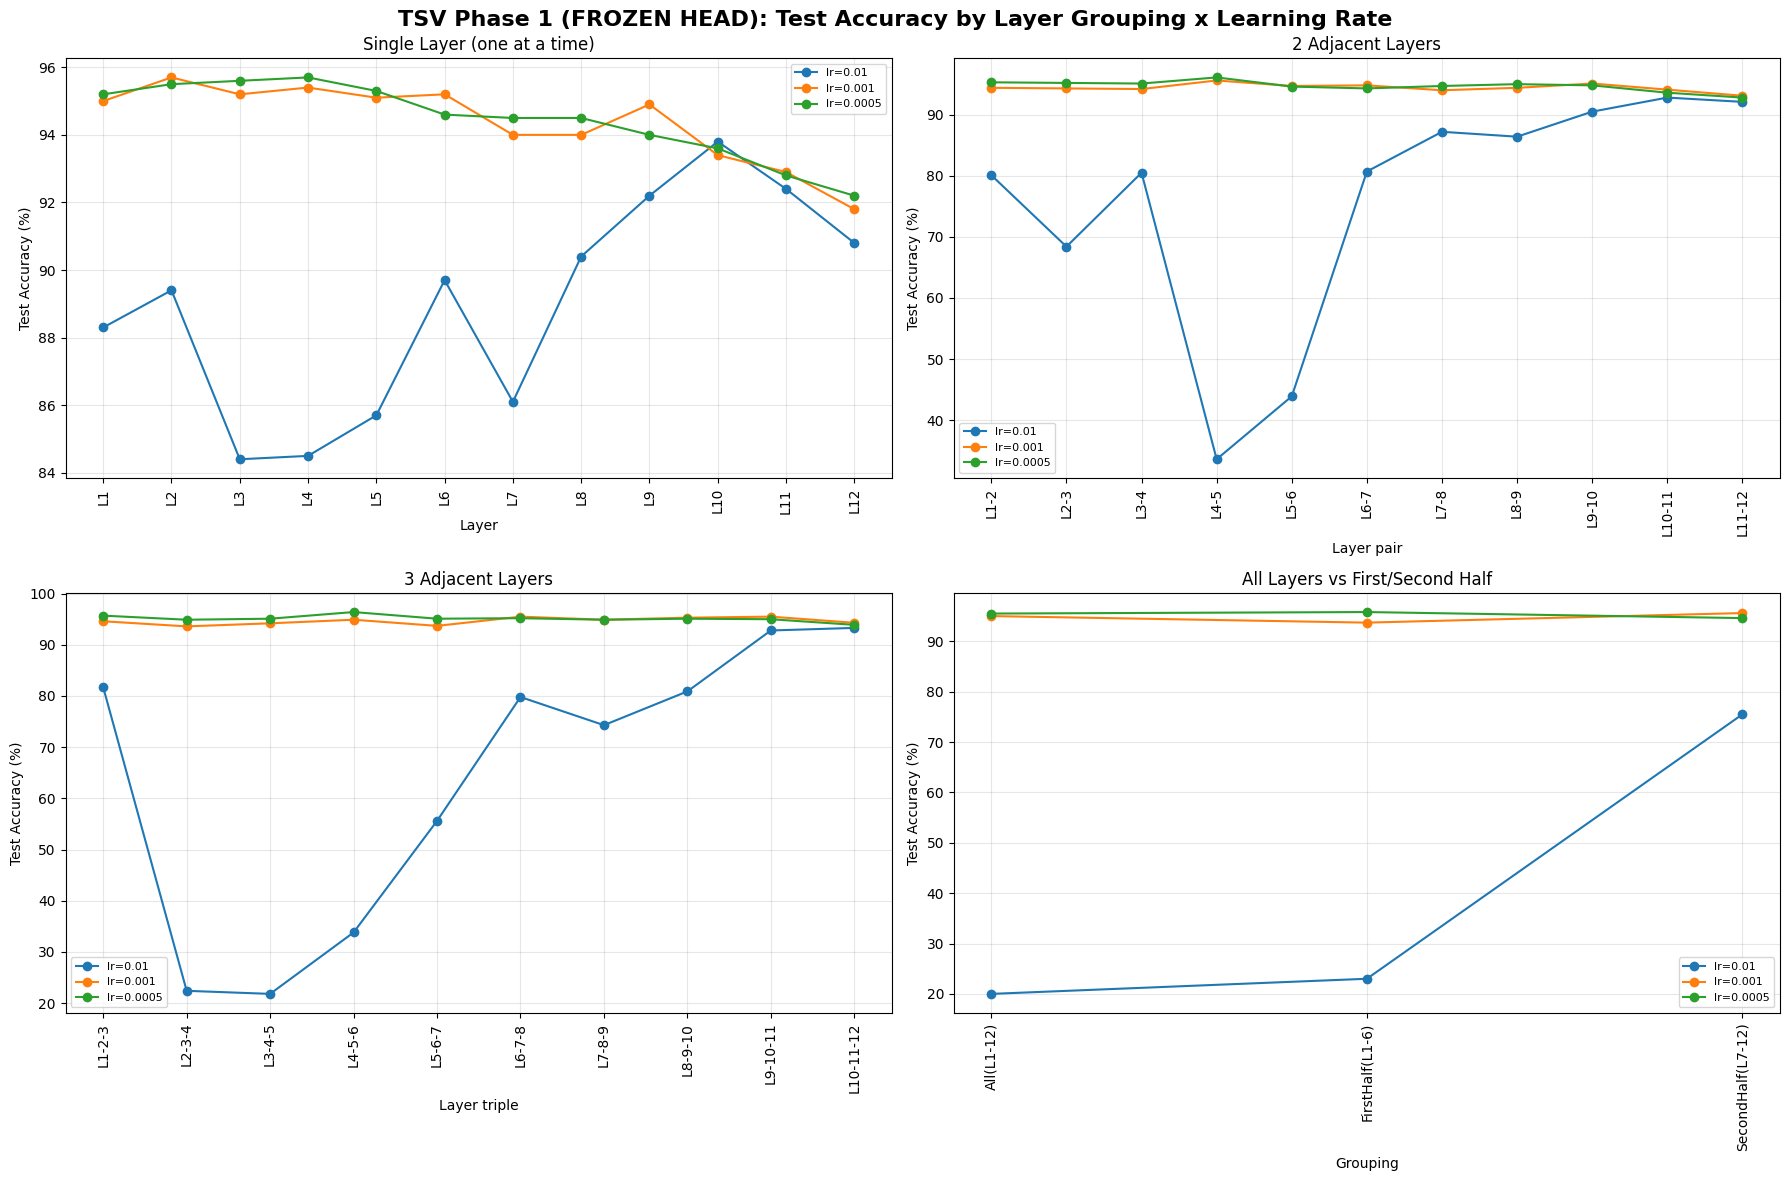


Top 10 (layer grouping, learning rate) combinations by accuracy -- FROZEN HEAD:
  L4-5-6               lr=0.0005   acc=96.40%  f1=0.9640
  L4-5                 lr=0.0005   acc=96.10%  f1=0.9611
  FirstHalf(L1-6)      lr=0.0005   acc=95.80%  f1=0.9580
  L2                   lr=0.001    acc=95.70%  f1=0.9569
  L4                   lr=0.0005   acc=95.70%  f1=0.9570
  L1-2-3               lr=0.0005   acc=95.70%  f1=0.9569
  L3                   lr=0.0005   acc=95.60%  f1=0.9560
  L4-5                 lr=0.001    acc=95.60%  f1=0.9562
  SecondHalf(L7-12)    lr=0.001    acc=95.60%  f1=0.9559
  L2                   lr=0.0005   acc=95.50%  f1=0.9550


In [20]:
# Same 4-panel graph style as the trainable-head Phase 1, now for the frozen head
frozen_singles  = [r for r in frozen_phase1_results if r['name'].startswith('L') and '-' not in r['name']]
frozen_pairs    = [r for r in frozen_phase1_results if r['name'].startswith('L') and r['name'].count('-') == 1]
frozen_triples  = [r for r in frozen_phase1_results if r['name'].startswith('L') and r['name'].count('-') == 2]
frozen_specials = [r for r in frozen_phase1_results if r['name'] in ('All(L1-12)', 'FirstHalf(L1-6)', 'SecondHalf(L7-12)')]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('TSV Phase 1 (FROZEN HEAD): Test Accuracy by Layer Grouping x Learning Rate', fontsize=16, fontweight='bold')

plot_group(axes[0,0], frozen_singles, 'Single Layer (one at a time)', 'Layer')
plot_group(axes[0,1], frozen_pairs, '2 Adjacent Layers', 'Layer pair')
plot_group(axes[1,0], frozen_triples, '3 Adjacent Layers', 'Layer triple')
plot_group(axes[1,1], frozen_specials, 'All Layers vs First/Second Half', 'Grouping')

plt.tight_layout()
plt.savefig('tsv_frozen_phase1_layer_groupings.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 (layer grouping, learning rate) combinations by accuracy -- FROZEN HEAD:")
for r in sorted(frozen_phase1_results, key=lambda r: -r['test_acc'])[:10]:
    print(f"  {r['name']:<20} lr={r['lr']:<8} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Phase 2 (Frozen Head): Placement (`where`) Sweep (6 runs, best layer grouping + learning rate from frozen Phase 1, `lam=5.0` fixed, `EPOCHS=10`)

In [21]:
frozen_best_layers = best_frozen_phase1['layer_indices']
frozen_best_layers_name = best_frozen_phase1['name']
frozen_best_lr = best_frozen_phase1['lr']
frozen_phase2_results = []

print("="*70)
print(f"PHASE 2 (FROZEN HEAD): PLACEMENT SWEEP  (layers={frozen_best_layers} [{frozen_best_layers_name}], lr={frozen_best_lr}, lam=5.0 fixed, epochs={EPOCHS})")
print("="*70)

frozen_phase2_start = time.time()
for w in wheres:
    print(f"\n--- where='{w}' ---")
    result = run_tsv_experiment_frozen(layer_indices=frozen_best_layers, where=w, lam=5.0, epochs=EPOCHS, lr=frozen_best_lr)
    result['name'] = w
    frozen_phase2_results.append(result)

frozen_phase2_elapsed = time.time() - frozen_phase2_start
print(f"\nFrozen-head Phase 2 total time: {frozen_phase2_elapsed/60:.1f} minutes")

best_frozen_phase2 = max(frozen_phase2_results, key=lambda r: r['test_acc'])
print(f"\nBest placement (frozen head): where='{best_frozen_phase2['where']}' -> {best_frozen_phase2['test_acc']:.2f}% acc")


PHASE 2 (FROZEN HEAD): PLACEMENT SWEEP  (layers=[3, 4, 5] [L4-5-6], lr=0.0005, lam=5.0 fixed, epochs=10)

--- where='residual' ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

      epoch 1/10: train_loss=0.2329  train_acc=92.36%


      epoch 2/10: train_loss=0.2025  train_acc=93.58%


      epoch 3/10: train_loss=0.1659  train_acc=94.70%


...

      epoch 7/10: train_loss=0.1815  train_acc=93.86%


      epoch 8/10: train_loss=0.1863  train_acc=93.70%


      epoch 9/10: train_loss=0.1700  train_acc=94.30%


      epoch 10/10: train_loss=0.1565  train_acc=94.76%


    layers=[3, 4, 5]  where=mlp_residual  lam=5.0  lr=0.0005  -> acc=95.80%  f1=0.9580  (74.3s)

Frozen-head Phase 2 total time: 7.8 minutes

Best placement (frozen head): where='attn' -> 96.50% acc


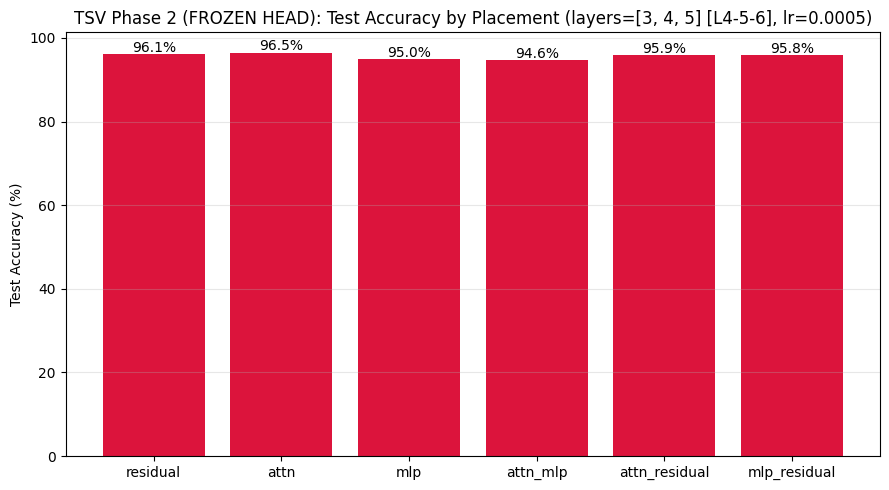


All frozen-head Phase 2 results, sorted:
  where=attn            acc=96.50%  f1=0.9650
  where=residual        acc=96.10%  f1=0.9611
  where=attn_residual   acc=95.90%  f1=0.9590
  where=mlp_residual    acc=95.80%  f1=0.9580
  where=mlp             acc=95.00%  f1=0.9496
  where=attn_mlp        acc=94.60%  f1=0.9462


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
names = [r['name'] for r in frozen_phase2_results]
accs = [r['test_acc'] for r in frozen_phase2_results]
bars = ax.bar(names, accs, color='crimson')
ax.set_title(f"TSV Phase 2 (FROZEN HEAD): Test Accuracy by Placement (layers={frozen_best_layers} [{frozen_best_layers_name}], lr={frozen_best_lr})")
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_frozen_phase2_where.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll frozen-head Phase 2 results, sorted:")
for r in sorted(frozen_phase2_results, key=lambda r: -r['test_acc']):
    print(f"  where={r['where']:<15} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Phase 3 (Frozen Head): Steering Strength (`lam`) Sweep (5 runs, best layer grouping + placement + learning rate from frozen Phases 1-2, `EPOCHS=10`)

In [23]:
frozen_best_where = best_frozen_phase2['where']
frozen_phase3_results = []

print("="*70)
print(f"PHASE 3 (FROZEN HEAD): STEERING STRENGTH SWEEP  (layers={frozen_best_layers} [{frozen_best_layers_name}], where='{frozen_best_where}', lr={frozen_best_lr}, epochs={EPOCHS})")
print("="*70)

frozen_phase3_start = time.time()
for lam in lams:
    print(f"\n--- lam={lam} ---")
    result = run_tsv_experiment_frozen(layer_indices=frozen_best_layers, where=frozen_best_where, lam=lam, epochs=EPOCHS, lr=frozen_best_lr)
    result['name'] = f'lam={lam}'
    frozen_phase3_results.append(result)

frozen_phase3_elapsed = time.time() - frozen_phase3_start
print(f"\nFrozen-head Phase 3 total time: {frozen_phase3_elapsed/60:.1f} minutes")

best_frozen_phase3 = max(frozen_phase3_results, key=lambda r: r['test_acc'])
print(f"\nBest steering strength (frozen head): lam={best_frozen_phase3['lam']} -> {best_frozen_phase3['test_acc']:.2f}% acc")


PHASE 3 (FROZEN HEAD): STEERING STRENGTH SWEEP  (layers=[3, 4, 5] [L4-5-6], where='attn', lr=0.0005, epochs=10)

--- lam=0.1 ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

      epoch 1/10: train_loss=0.3616  train_acc=88.66%


      epoch 2/10: train_loss=0.3056  train_acc=90.02%


      epoch 3/10: train_loss=0.2723  train_acc=91.38%


...

      epoch 7/10: train_loss=0.1540  train_acc=94.82%


      epoch 8/10: train_loss=0.1491  train_acc=94.74%


      epoch 9/10: train_loss=0.1635  train_acc=94.34%


      epoch 10/10: train_loss=0.1550  train_acc=94.68%


    layers=[3, 4, 5]  where=attn  lam=10  lr=0.0005  -> acc=96.20%  f1=0.9618  (75.7s)

Frozen-head Phase 3 total time: 6.6 minutes

Best steering strength (frozen head): lam=10 -> 96.20% acc


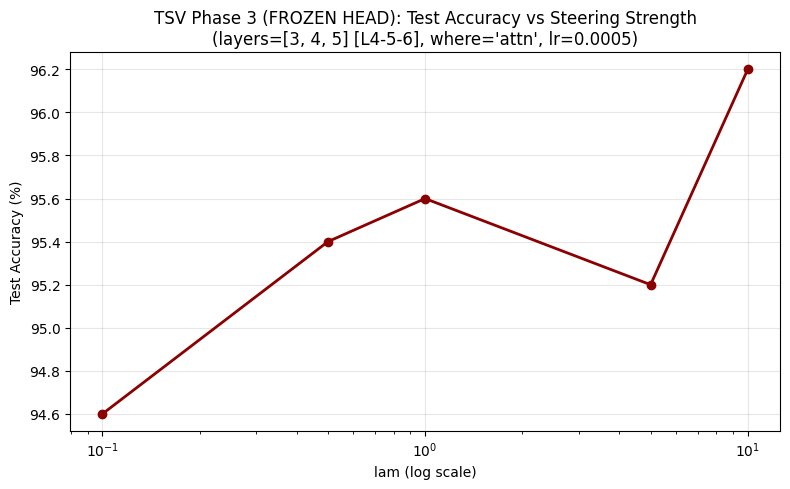


All frozen-head Phase 3 results:
  lam=0.1    acc=94.60%  f1=0.9462
  lam=0.5    acc=95.40%  f1=0.9540
  lam=1      acc=95.60%  f1=0.9561
  lam=5      acc=95.20%  f1=0.9520
  lam=10     acc=96.20%  f1=0.9618


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['lam'] for r in frozen_phase3_results]
ys = [r['test_acc'] for r in frozen_phase3_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='darkred')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 3 (FROZEN HEAD): Test Accuracy vs Steering Strength\n(layers={frozen_best_layers} [{frozen_best_layers_name}], where='{frozen_best_where}', lr={frozen_best_lr})")
ax.set_xlabel('lam (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_frozen_phase3_lam.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll frozen-head Phase 3 results:")
for r in frozen_phase3_results:
    print(f"  lam={r['lam']:<6} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")

frozen_best_lam = best_frozen_phase3['lam']


### Phase 4 (Frozen Head): Training Set Size Sweep (5 runs, `EPOCHS=10`)

In [25]:
frozen_train_sizes = [100, 500, 1000, 2500, 5000]
frozen_phase4_results = []

print("="*70)
print(f"PHASE 4 (FROZEN HEAD): TRAINING SET SIZE SWEEP  (layers={frozen_best_layers}, where='{frozen_best_where}', lam={frozen_best_lam}, lr={frozen_best_lr}, epochs={EPOCHS})")
print("="*70)

frozen_phase4_start = time.time()
for size in frozen_train_sizes:
    print(f"\n--- train_size={size} ---")
    if size < len(train_dataset):
        size_subset, _ = random_split(train_dataset, [size, len(train_dataset) - size])
    else:
        size_subset = train_dataset
    size_loader = DataLoader(size_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    result = run_tsv_experiment_frozen(frozen_best_layers, frozen_best_where, frozen_best_lam, EPOCHS, frozen_best_lr, size_loader)
    result['train_size'] = size
    frozen_phase4_results.append(result)

frozen_phase4_elapsed = time.time() - frozen_phase4_start
print(f"\nFrozen-head Phase 4 total time: {frozen_phase4_elapsed/60:.1f} minutes")

best_frozen_phase4 = max(frozen_phase4_results, key=lambda r: r['test_acc'])
print(f"\nBest training set size (frozen head): {best_frozen_phase4['train_size']} -> {best_frozen_phase4['test_acc']:.2f}% acc")


PHASE 4 (FROZEN HEAD): TRAINING SET SIZE SWEEP  (layers=[3, 4, 5], where='attn', lam=10, lr=0.0005, epochs=10)

--- train_size=100 ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

      epoch 1/10: train_loss=0.3155  train_acc=89.00%


      epoch 2/10: train_loss=0.1966  train_acc=95.00%


      epoch 3/10: train_loss=0.2571  train_acc=93.00%


...

      epoch 7/10: train_loss=0.1583  train_acc=94.76%


      epoch 8/10: train_loss=0.1539  train_acc=94.78%


      epoch 9/10: train_loss=0.1393  train_acc=95.26%


      epoch 10/10: train_loss=0.1546  train_acc=94.44%


    layers=[3, 4, 5]  where=attn  lam=10  lr=0.0005  -> acc=95.50%  f1=0.9550  (75.8s)

Frozen-head Phase 4 total time: 2.7 minutes

Best training set size (frozen head): 2500 -> 96.00% acc


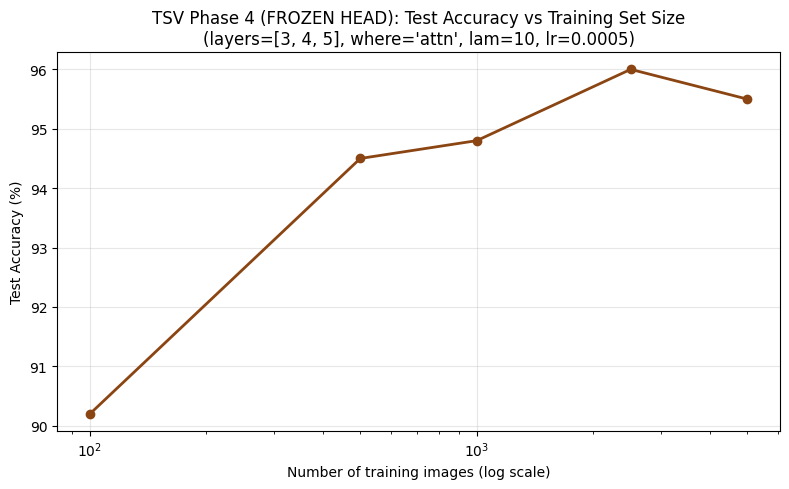


All frozen-head Phase 4 results:
  train_size=100    acc=90.20%  f1=0.9028
  train_size=500    acc=94.50%  f1=0.9448
  train_size=1000   acc=94.80%  f1=0.9482
  train_size=2500   acc=96.00%  f1=0.9601
  train_size=5000   acc=95.50%  f1=0.9550


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['train_size'] for r in frozen_phase4_results]
ys = [r['test_acc'] for r in frozen_phase4_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='saddlebrown')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 4 (FROZEN HEAD): Test Accuracy vs Training Set Size\n(layers={frozen_best_layers}, where='{frozen_best_where}', lam={frozen_best_lam}, lr={frozen_best_lr})")
ax.set_xlabel('Number of training images (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_frozen_phase4_train_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll frozen-head Phase 4 results:")
for r in frozen_phase4_results:
    print(f"  train_size={r['train_size']:<6} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Phase 5 (Frozen Head): Batch Size Sweep (4 runs, `EPOCHS=10`)

In [27]:
frozen_batch_sizes = [16, 32, 64, 128]
frozen_phase5_results = []

print("="*70)
print(f"PHASE 5 (FROZEN HEAD): BATCH SIZE SWEEP  (layers={frozen_best_layers}, where='{frozen_best_where}', lam={frozen_best_lam}, lr={frozen_best_lr}, epochs={EPOCHS})")
print("="*70)

frozen_phase5_start = time.time()
for bs in frozen_batch_sizes:
    print(f"\n--- batch_size={bs} ---")
    bs_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)

    result = run_tsv_experiment_frozen(frozen_best_layers, frozen_best_where, frozen_best_lam, EPOCHS, frozen_best_lr, bs_loader)
    result['batch_size'] = bs
    frozen_phase5_results.append(result)

frozen_phase5_elapsed = time.time() - frozen_phase5_start
print(f"\nFrozen-head Phase 5 total time: {frozen_phase5_elapsed/60:.1f} minutes")

best_frozen_phase5 = max(frozen_phase5_results, key=lambda r: r['test_acc'])
print(f"\nBest batch size (frozen head): {best_frozen_phase5['batch_size']} -> {best_frozen_phase5['test_acc']:.2f}% acc")


PHASE 5 (FROZEN HEAD): BATCH SIZE SWEEP  (layers=[3, 4, 5], where='attn', lam=10, lr=0.0005, epochs=10)

--- batch_size=16 ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

      epoch 1/10: train_loss=0.2723  train_acc=90.54%


      epoch 2/10: train_loss=0.2343  train_acc=92.18%


      epoch 3/10: train_loss=0.2484  train_acc=92.00%


...

      epoch 7/10: train_loss=0.1460  train_acc=95.30%


      epoch 8/10: train_loss=0.1658  train_acc=94.58%


      epoch 9/10: train_loss=0.1505  train_acc=95.12%


      epoch 10/10: train_loss=0.1384  train_acc=95.12%


    layers=[3, 4, 5]  where=attn  lam=10  lr=0.0005  -> acc=95.60%  f1=0.9559  (72.5s)

Frozen-head Phase 5 total time: 5.4 minutes

Best batch size (frozen head): 128 -> 95.60% acc


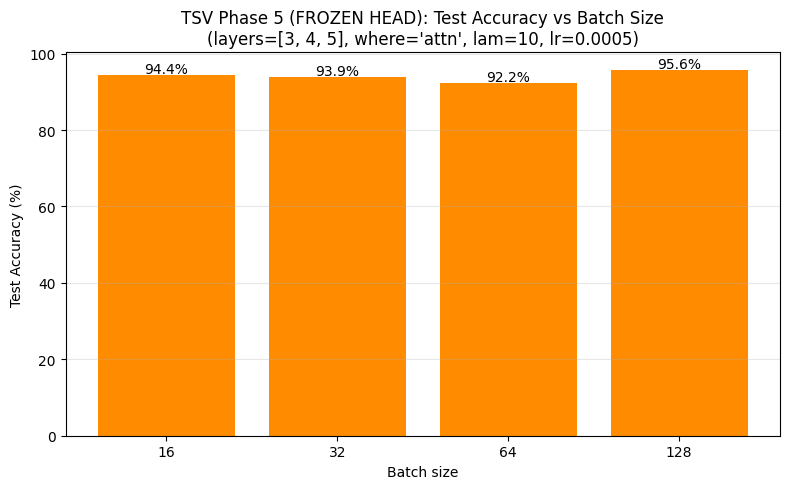


All frozen-head Phase 5 results:
  batch_size=16    acc=94.40%  f1=0.9442
  batch_size=32    acc=93.90%  f1=0.9393
  batch_size=64    acc=92.20%  f1=0.9207
  batch_size=128   acc=95.60%  f1=0.9559


In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
names = [str(r['batch_size']) for r in frozen_phase5_results]
accs = [r['test_acc'] for r in frozen_phase5_results]
bars = ax.bar(names, accs, color='darkorange')
ax.set_title(f"TSV Phase 5 (FROZEN HEAD): Test Accuracy vs Batch Size\n(layers={frozen_best_layers}, where='{frozen_best_where}', lam={frozen_best_lam}, lr={frozen_best_lr})")
ax.set_xlabel('Batch size')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_frozen_phase5_batch_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll frozen-head Phase 5 results:")
for r in frozen_phase5_results:
    print(f"  batch_size={r['batch_size']:<5} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Summary: Saving Frozen-Head Results

In [29]:
from pathlib import Path
import shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

frozen_only_summary = {
    'frozen_phase1_layer_lr_groupings': frozen_phase1_results,
    'frozen_phase2_where': frozen_phase2_results,
    'frozen_phase3_lam': frozen_phase3_results,
    'frozen_phase4_train_size': frozen_phase4_results,
    'frozen_phase5_batch_size': frozen_phase5_results,
    'best_frozen_phase1': best_frozen_phase1,
    'best_frozen_phase2': best_frozen_phase2,
    'best_frozen_phase3': best_frozen_phase3,
    'best_frozen_phase4': best_frozen_phase4,
    'best_frozen_phase5': best_frozen_phase5,
    'total_time_minutes': (frozen_phase1_elapsed + frozen_phase2_elapsed + frozen_phase3_elapsed
                            + frozen_phase4_elapsed + frozen_phase5_elapsed) / 60,
}

with open(results_dir / save_name('tsv_frozen_only_study', 'json'), 'w') as f:
    json.dump(frozen_only_summary, f, indent=2)

all_pngs = [
    'tsv_frozen_phase1_layer_groupings.png', 'tsv_frozen_phase2_where.png',
    'tsv_frozen_phase3_lam.png', 'tsv_frozen_phase4_train_size.png',
    'tsv_frozen_phase5_batch_size.png',
]
for fname in all_pngs:
    base = fname.rsplit('.', 1)[0]
    shutil.copy(fname, results_dir / save_name(base, 'png'))

print(f"\u2713 Frozen-head-only study (5 phases, {len(all_pngs)} graphs) saved to {results_dir}")
print(f"  Total time: {frozen_only_summary['total_time_minutes']:.1f} minutes")
print(f"\nBest frozen-head configuration:")
best_all = max([best_frozen_phase1, best_frozen_phase2, best_frozen_phase3,
                best_frozen_phase4, best_frozen_phase5], key=lambda r: r['test_acc'])
print(f"  {best_all}")


✓ Frozen-head-only study (5 phases, 5 graphs) saved to /content/drive/MyDrive/PEFT_Results
  Total time: 153.1 minutes

Best frozen-head configuration:
  {'layer_indices': [3, 4, 5], 'where': 'attn', 'lam': 5.0, 'lr': 0.0005, 'test_acc': 96.5, 'test_f1': 0.9650203133347796, 'trainable_params': 2304, 'time_seconds': 75.45200896263123, 'name': 'attn'}
